In [1]:
import os

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install kagglehub opencv-python matplotlib tqdm
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [3]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("brunobelloni/outdoor-training-set-ots-reside")

print("Dataset path:", path)

100%|██████████| 11.1G/11.1G [01:58<00:00, 100MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/brunobelloni/outdoor-training-set-ots-reside/versions/3


In [4]:
import random
import os

hazy_dir = "/content/drive/MyDrive/IPML_Project/dataset/train/hazy"
clear_dir = "/content/drive/MyDrive/IPML_Project/dataset/train/clear"

hazy_files = os.listdir(hazy_dir)

random.seed(42)
# keep only valid pairs
valid_files = []

for f in hazy_files:
    base_name = f.split('_')[0] + ".jpg"
    clear_path = os.path.join(clear_dir, base_name)

    if os.path.exists(clear_path):
        valid_files.append(f)

print("Total valid pairs:", len(valid_files))

# randomly select 1000 images because in paper 200 images are used for training purpose
selected_files = random.sample(valid_files, 1000)

print("Selected pairs:", len(selected_files))

Total valid pairs: 5832
Selected pairs: 1000


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [6]:
class DehazeDataset(Dataset):
    def __init__(self, hazy_dir, clear_dir, size=224, limit=500):
        self.hazy_dir = hazy_dir
        self.clear_dir = clear_dir
        self.size = size

        all_hazy = os.listdir(hazy_dir)

        valid_files = []

        for f in all_hazy:
            base_name = f.split('_')[0] + ".jpg"
            if os.path.exists(os.path.join(clear_dir, base_name)):
                valid_files.append(f)

        print(f"Total valid pairs: {len(valid_files)}")

        # Use only 200 samples (as mentioned in the paper)
        import random
        random.seed(42)
        self.hazy_images = random.sample(valid_files, min(limit, len(valid_files)))

        print(f"Using {len(self.hazy_images)} samples")

    def __len__(self):
        return len(self.hazy_images)

    def __getitem__(self, idx):
        hazy_name = self.hazy_images[idx]
        base_name = hazy_name.split('_')[0] + ".jpg"

        hazy_path = os.path.join(self.hazy_dir, hazy_name)
        clear_path = os.path.join(self.clear_dir, base_name)

        hazy = cv2.imread(hazy_path)
        clear = cv2.imread(clear_path)

        hazy = cv2.resize(hazy, (self.size, self.size))
        clear = cv2.resize(clear, (self.size, self.size))

        hazy = cv2.cvtColor(hazy, cv2.COLOR_BGR2RGB)
        clear = cv2.cvtColor(clear, cv2.COLOR_BGR2RGB)

        # ensure float32
        hazy = hazy.astype(np.float32) / 255.0
        clear = clear.astype(np.float32) / 255.0

        # Dark channel
        dark = np.min(hazy, axis=2, keepdims=True)

        # Illumination channel
        illum = (
            0.299 * hazy[:,:,0] +
            0.587 * hazy[:,:,1] +
            0.144 * hazy[:,:,2]
        )[..., np.newaxis]

        # Concatenate -> 5 channels
        input_5ch = np.concatenate([hazy, dark, illum], axis=2)

        input_5ch = torch.from_numpy(input_5ch).permute(2,0,1)
        clear = torch.from_numpy(clear).permute(2,0,1)

        return input_5ch, clear

In [7]:
class CSIDNet(nn.Module):
    def __init__(self):
        super(CSIDNet, self).__init__()

        # Pre-activation
        self.pre_bn = nn.BatchNorm2d(5)
        self.pre_act = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout2d(0.2)

        # Conv layers
        self.conv1 = nn.Conv2d(5, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 16, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)

        self.conv3 = nn.Conv2d(16, 5, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(5)

        self.act = nn.LeakyReLU(0.2)
        self._initialize_weights()

    def _initialize_weights(self):
      for m in self.modules():
          if isinstance(m, nn.Conv2d):
              nn.init.kaiming_uniform_(m.weight, nonlinearity='leaky_relu')
              if m.bias is not None:
                  nn.init.zeros_(m.bias)

    def forward(self, x):
        input_x = x  # for skip connection

        # Pre-activation
        x = self.pre_bn(x)
        x = self.pre_act(x)
        x = self.dropout(x)

        # Layer 1
        x = self.act(self.bn1(self.conv1(x)))

        # Layer 2
        x = self.act(self.bn2(self.conv2(x)))

        # Layer 3
        x = self.bn3(self.conv3(x))

        # Skip connection
        x = x + input_x

        # Sigmoid activation
        x = torch.sigmoid(x)

        return x

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = CSIDNet().to(device)

# Define losses
mse_loss = nn.MSELoss()
l1_loss = nn.L1Loss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999)
)

# criterion = nn.MSELoss()
# Combined loss function
def hybrid_loss(pred, target):
    return 0.8 * mse_loss(pred, target) + 0.2 * l1_loss(pred, target)

Using device: cuda


In [9]:
def train(model, dataloader, optimizer, criterion, epochs=20):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in tqdm(dataloader):
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            output = model(x)

            #take only RGB channels
            output_rgb = output[:, :3, :, :]

            # loss = criterion(output_rgb, y)
            loss = hybrid_loss(output_rgb, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)

        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

In [ ]:
#Reproducibility
import random
import numpy as np
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Dataset (IMPORTANT: limit = 200)
train_dataset = DehazeDataset(
    "/content/drive/MyDrive/IPML_Project/dataset/train/hazy",
    "/content/drive/MyDrive/IPML_Project/dataset/train/clear",
    limit=500
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2   # faster
)

# Train
train(model, train_loader, optimizer, hybrid_loss, epochs=100)

Total valid pairs: 5832
Using 500 samples


100%|██████████| 63/63 [03:23<00:00,  3.23s/it]


Epoch 1, Loss: 0.1239


100%|██████████| 63/63 [00:12<00:00,  4.95it/s]


Epoch 2, Loss: 0.0751


...

100%|██████████| 63/63 [00:13<00:00,  4.84it/s]


Epoch 6, Loss: 0.0548


100%|██████████| 63/63 [00:13<00:00,  4.77it/s]


Epoch 7, Loss: 0.0529


 75%|███████▍  | 47/63 [00:10<00:03,  4.02it/s]

In [ ]:
def dehaze_image(model, image_path):
    model.eval()

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original = img.copy()

    img = cv2.resize(img, (224,224)).astype(np.float32) / 255.0

    # Dark channel
    dark = np.min(img, axis=2, keepdims=True)

    # Illumination channel
    illum = (
        0.299*img[:,:,0] +
        0.587*img[:,:,1] +
        0.144*img[:,:,2]
    )[..., np.newaxis]

    # 5-channel input
    input_5ch = np.concatenate([img, dark, illum], axis=2)
    input_5ch = torch.from_numpy(input_5ch).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_5ch)

        # take only RGB channels
        output = output[:, :3, :, :]

    output = output.squeeze().permute(1,2,0).cpu().numpy()
    output = np.clip(output, 0, 1)

    # Resize back to original size
    output = cv2.resize(output, (original.shape[1], original.shape[0]))

    return original, output

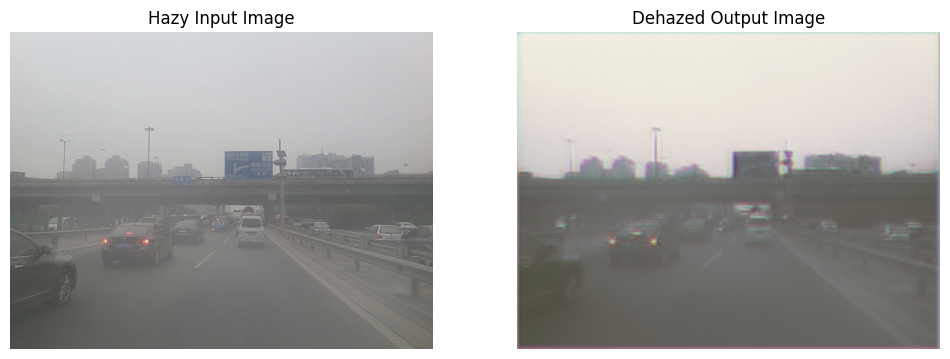

In [ ]:
input_img, output_img = dehaze_image(
    model,
    "/content/drive/MyDrive/IPML_Project/test_3.jpg"
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(input_img / 255.0)   # normalize for display
plt.title("Hazy Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output_img)          # already clipped
plt.title("Dehazed Output Image")
plt.axis("off")

plt.show()

PSNR and SSIM Metrics for Evaluation of model

In [ ]:
import numpy as np

def compute_psnr(pred, target):
    pred = np.clip(pred, 0, 1)
    target = np.clip(target, 0, 1)

    mse = np.mean((pred - target) ** 2)

    if mse == 0:
        return 100

    return 20 * np.log10(1.0 / np.sqrt(mse))


from skimage.metrics import structural_similarity as ssim

def compute_ssim(pred, target):
    pred = np.clip(pred, 0, 1)
    target = np.clip(target, 0, 1)

    return ssim(pred, target, channel_axis=2, data_range=1.0)

original, output = dehaze_image(model, "/Screenshot 2026-04-17 231838.png")

gt_path = "/Screenshot 2026-04-17 231838.png"

gt = cv2.imread(gt_path)
gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)
gt = gt.astype(np.float32) / 255.0
gt = cv2.resize(gt, (output.shape[1], output.shape[0]))

psnr_val = compute_psnr(output, gt)
ssim_val = compute_ssim(output, gt)

print("PSNR:", psnr_val)
print("SSIM:", ssim_val)

Save the model

In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/IPML_Project/csidnet_model.pth"
)

Next time when you open the colab do this

In [ ]:
model = CSIDNet().to(device)

In [ ]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/IPML_Project/csidnet_model.pth")
)

<All keys matched successfully>

In [ ]:
model.eval()

CSIDNet(
  (pre_bn): BatchNorm2d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pre_act): LeakyReLU(negative_slope=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (conv1): Conv2d(5, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(16, 5, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): LeakyReLU(negative_slope=0.2)
  (sigmoid): Sigmoid()
)

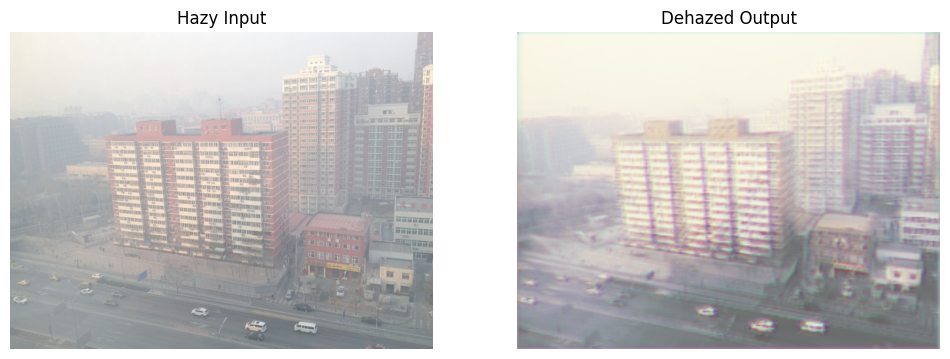

In [ ]:
input_img, output_img = dehaze_image(
    model,
    "/content/drive/MyDrive/IPML_Project/test.jpg"
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(input_img)
plt.title("Hazy Input")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(np.clip(output_img, 0, 1))
plt.title("Dehazed Output")
plt.axis("off")

plt.show()

In [ ]:
!pip install scikit-image

In [ ]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

In [ ]:
def evaluate_metrics(pred, target):
    """
    pred   : predicted image (H, W, 3) → range [0,1]
    target : ground truth image (H, W, 3) → range [0,1]
    """

    # Convert to numpy if tensor
    if isinstance(pred, torch.Tensor):
        pred = pred.permute(1,2,0).cpu().numpy()
    if isinstance(target, torch.Tensor):
        target = target.permute(1,2,0).cpu().numpy()

    # PSNR
    psnr_value = peak_signal_noise_ratio(target, pred, data_range=1.0)

    # SSIM
    ssim_value = structural_similarity(target, pred, multichannel=True, data_range=1.0)

    return psnr_value, ssim_value